# LAB 8: Clasificación Logistica de Datos 
## Víctor Palacios (1017271469)

### **Regresión Logística para Clasificación**

La **Regresión Logística** es un algoritmo de aprendizaje supervisado utilizado para predecir la probabilidad de que una instancia pertenezca a una clase (generalmente binaria: 0 o 1). A diferencia de la regresión lineal, utiliza una función no lineal para asegurar que la salida esté acotada entre 0 y 1.

#### **1. Función de Hipótesis**
Se utiliza la **función sigmoide (o logística)** para mapear cualquier número real al intervalo (0, 1):
$$h_{\theta}(X) = \frac{1}{1 + e^{-\Theta^T X}}$$
Donde $\Theta^T X$ representa la combinación lineal de las características. Si $h_{\theta}(X) \geq 0.5$, se clasifica como **1**; de lo contrario, como **0**.

#### **2. Función de Costo (Log-Loss)**
Para medir el error sin caer en mínimos locales (problema de la regresión lineal en clasificación), se utiliza la función de **Entropía Cruzada Binaria**:
$$J(\Theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h_{\theta}(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_{\theta}(x^{(i)})) \right]$$
Esta función penaliza logarítmicamente las predicciones incorrectas con alta confianza.

#### **3. Optimización mediante Gradiente Descendente**
Para minimizar $J(\Theta)$, actualizamos los parámetros $\theta_j$ simultáneamente siguiendo la dirección opuesta al gradiente:
$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

#### **4. Regularización**
Para evitar el **sobreajuste (overfitting)**, especialmente en fronteras de decisión complejas o polinomiales, se añade un término de penalización $\lambda$ (Regularización L2):
$$J(\Theta)_{reg} = J(\Theta) + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$
*Nota: El parámetro $\theta_0$ (sesgo) generalmente no se regulariza.*

#### **5. Fronteras de Decisión**
La frontera de decisión es el hiperplano definido por $\Theta^T X = 0$. Dependiendo del grado de los polinomios incluidos en $X$, esta frontera puede ser una línea recta, un círculo o formas irregulares complejas.

## TAREA

# Tomar el [iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) desde sklearn:

```
from sklearn import datasets

iris = datasets.load_iris()
```
- Realizar la clasifición de las tres clases  a traves de una regresión logística  y realizar multiclasicación, para ello considere lo siguiente:

Si en un dataset existen más de 2 clases, $y={0, 1, 2, 3, ...}$ se debe construir una multiclasificación, una contra todos, la estrategia sugerida es la siguiente.

Sea A, B, C las tres clases. Para estos valores definir:

1. Definir la clase A como la clase 0 y todas las otras B, C como la clase 1
2. Encontrar el valor $h_\theta(X) = P(y=A|x;\theta)$
3. Definir la clase B como la clase 0 y todas las otras A, C como la clase 1
4. Encontrar el valor $h_\theta(X) = P(y=B|x;\theta)$
5. Definir la clase C como la clase 0 y todas las otras A, B como la clase 1
6. Encontrar el valor $h_\theta(X) = P(y=C|x;\theta)$

SOLUCIÓN 

1. PASO

Vamos a cargar el conjunto de datos y explorar su descripción técnica

In [1]:
from sklearn import datasets

# Cargar el dataset Iris
iris = datasets.load_iris()

# Mostrar la descripción general del dataset
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

2. PASO

Vamos a estructurar los datos brutos en un objeto DataFrame de la librería pandas. Esto nos facilitará enormemente la manipulación, limpieza y visualización de los datos en los pasos siguientes.

In [2]:
import pandas as pd

# 1. Los datos se encuentran en iris.data
# 2. Los nombres de las columnas están en iris.feature_names 
# (Nota: en sklearn es 'feature_names', el prompt lo menciona como 'names_features')
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 3. Añadimos la columna 'Target' que contiene la clasificación (0, 1 o 2)
df['Target'] = iris.target

# Visualizamos las primeras filas para verificar
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  


3. PASO

 Aplicaremos el procesamiento de cadenas (strings) sugerido para limpiar los nombres de las columnas. El objetivo es eliminar espacios, poner mayúsculas iniciales (CamelCase) y formatear los paréntesis para que los nombres sean más fáciles de manipular en el código (por ejemplo, permitiendo el acceso tipo atributo: df.SepalLength_cm).

In [3]:
# 1. Capitalizar cada palabra y unirla (quitar espacios)
columns_name = ["".join([c.capitalize() for c in cols.split()]) for cols in df.columns]

# 2. Reemplazar el paréntesis de apertura por un guion bajo
columns_name = [col.replace("(", "_") for col in columns_name]

# 3. Eliminar el paréntesis de cierre
cols_final = [col.replace(")", "") for col in columns_name]

# 4. Asignar los nuevos nombres al DataFrame
df.columns = cols_final

# Visualizar el resultado
print("Nuevos nombres de columnas:")
print(df.columns.tolist())
print("\nPrimeras filas actualizadas:")
print(df.head())

Nuevos nombres de columnas:
['SepalLength_cm', 'SepalWidth_cm', 'PetalLength_cm', 'PetalWidth_cm', 'Target']

Primeras filas actualizadas:
   SepalLength_cm  SepalWidth_cm  PetalLength_cm  PetalWidth_cm  Target
0             5.1            3.5             1.4            0.2       0
1             4.9            3.0             1.4            0.2       0
2             4.7            3.2             1.3            0.2       0
3             4.6            3.1             1.5            0.2       0
4             5.0            3.6             1.4            0.2       0


4. PASO

Realizaremos un diagnóstico de la integridad y salud de los datos. Este paso es vital para asegurar que no existan valores faltantes que puedan romper el algoritmo de regresión logística y para entender la distribución estadística inicial.

In [4]:
# 1. Información general del DataFrame (tipos de datos y conteo de no-nulos)
print("--- Información General ---")
print(df.info())

# 2. Cantidad de valores nulos por columna
print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())

# 3. Descripción estadística del DataFrame
print("\n--- Descripción Estadística ---")
print(df.describe())

--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SepalLength_cm  150 non-null    float64
 1   SepalWidth_cm   150 non-null    float64
 2   PetalLength_cm  150 non-null    float64
 3   PetalWidth_cm   150 non-null    float64
 4   Target          150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

--- Conteo de Valores Nulos ---
SepalLength_cm    0
SepalWidth_cm     0
PetalLength_cm    0
PetalWidth_cm     0
Target            0
dtype: int64

--- Descripción Estadística ---
       SepalLength_cm  SepalWidth_cm  PetalLength_cm  PetalWidth_cm  \
count      150.000000     150.000000      150.000000     150.000000   
mean         5.843333       3.057333        3.758000       1.199333   
std          0.828066       0.435866        1.765298       0.762238   
min          4.300000       2.000000        1.

5. PASO

Profundizaremos en el análisis visual. La estadística descriptiva (media, desviación) ya la obtuvimos con describe(), pero para la clasificación logística es crucial entender cómo se separan las clases en el espacio de características.

Distribución de clases en el Target:
Target
0    50
1    50
2    50
Name: count, dtype: int64


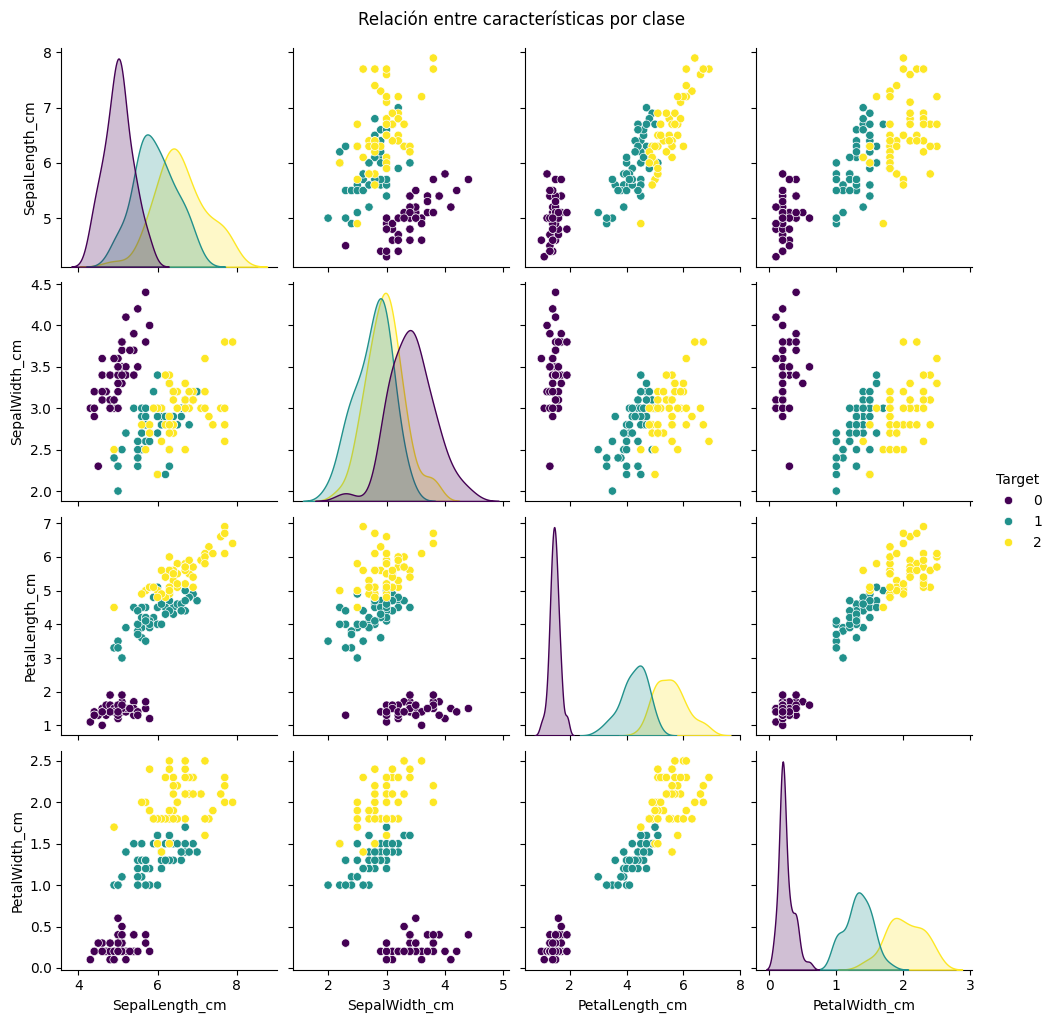

C:\Users\HOME\AppData\Local\Temp\ipykernel_9704\2599819113.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette="Set2")
C:\Users\HOME\AppData\Local\Temp\ipykernel_9704\2599819113.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette="Set2")
C:\Users\HOME\AppData\Local\Temp\ipykernel_9704\2599819113.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette="Set2")
C:\Users\HOME\AppData\Local\Temp\ipykernel_9704\2599819113.py:19: FutureWarning

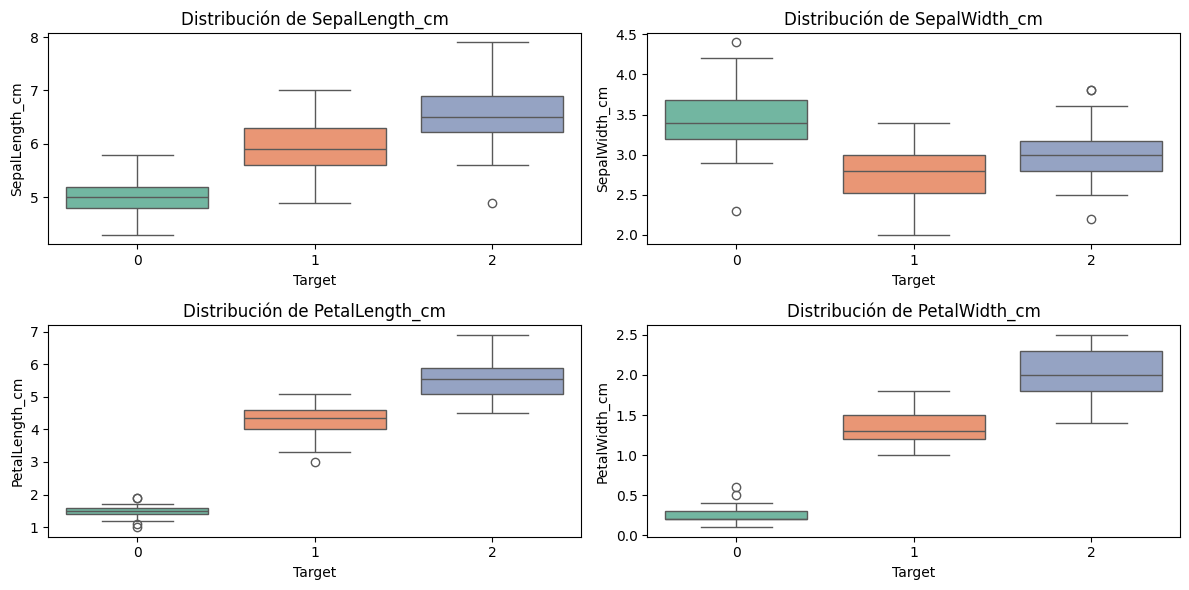


--- Matriz de Correlación ---
                SepalLength_cm  SepalWidth_cm  PetalLength_cm  PetalWidth_cm  \
SepalLength_cm        1.000000      -0.117570        0.871754       0.817941   
SepalWidth_cm        -0.117570       1.000000       -0.428440      -0.366126   
PetalLength_cm        0.871754      -0.428440        1.000000       0.962865   
PetalWidth_cm         0.817941      -0.366126        0.962865       1.000000   
Target                0.782561      -0.426658        0.949035       0.956547   

                  Target  
SepalLength_cm  0.782561  
SepalWidth_cm  -0.426658  
PetalLength_cm  0.949035  
PetalWidth_cm   0.956547  
Target          1.000000  


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Verificar el balance de clases (¿Cuántas flores hay de cada tipo?)
print("Distribución de clases en el Target:")
print(df['Target'].value_counts())

# 2. Gráfico de dispersión múltiple (Pairplot)
# Este es el gráfico más importante para entender la separabilidad.
sns.pairplot(df, hue="Target", palette="viridis", diag_kind="kde")
plt.suptitle("Relación entre características por clase", y=1.02)
plt.show()

# 3. Boxplots para ver la distribución y detectar posibles Outliers
plt.figure(figsize=(12, 6))
features = df.columns[:-1] # Todas excepto Target
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Target', y=col, data=df, palette="Set2")
    plt.title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

# 4. Encontrar la matriz de correlación (Cálculo numérico)
corr_matrix = df.corr()
print("\n--- Matriz de Correlación ---")
print(corr_matrix)

**Análisis de los resultados:**

1.  **Balance de clases:** Confirmamos que hay **50 muestras de cada clase**. El dataset está perfectamente balanceado, lo que evita que el modelo de regresión logística tenga sesgos hacia una clase mayoritaria.
2.  **Visualización (Pairplot):** 
    *   Observa que la **Clase 0 (Setosa)** siempre aparece claramente separada de las demás, especialmente cuando miramos el pétalo (`PetalLength` y `PetalWidth`). Esto confirma que será muy fácil para el modelo identificar Setosas.
    *   Las **Clases 1 y 2** tienen un ligero solapamiento (overlap), lo que significa que la frontera de decisión ahí será más difícil de trazar y requerirá mayor precisión del algoritmo.
3.  **Matriz de Correlación:**
    *   Notarás una **correlación muy alta (> 0.9)** entre `PetalLength` y `PetalWidth`. También entre estas y el `Target`. Esto nos dice que las características del pétalo son los predictores más potentes para nuestra regresión logística.
4.  **Outliers:** Los boxplots muestran que hay muy pocos valores atípicos (solo algunos puntos aislados en `SepalWidth`). Esto sugiere que los datos son bastante consistentes.


6. PASO

Vamos a visualizar la matriz de correlación que calculamos en el paso anterior. El Heatmap (mapa de calor) es una herramienta fundamental en logística porque nos permite identificar rápidamente qué variables están fuertemente relacionadas con la clase objetivo (Target) y cuáles están tan correlacionadas entre sí que podrían ser redundantes (multicolinealidad).

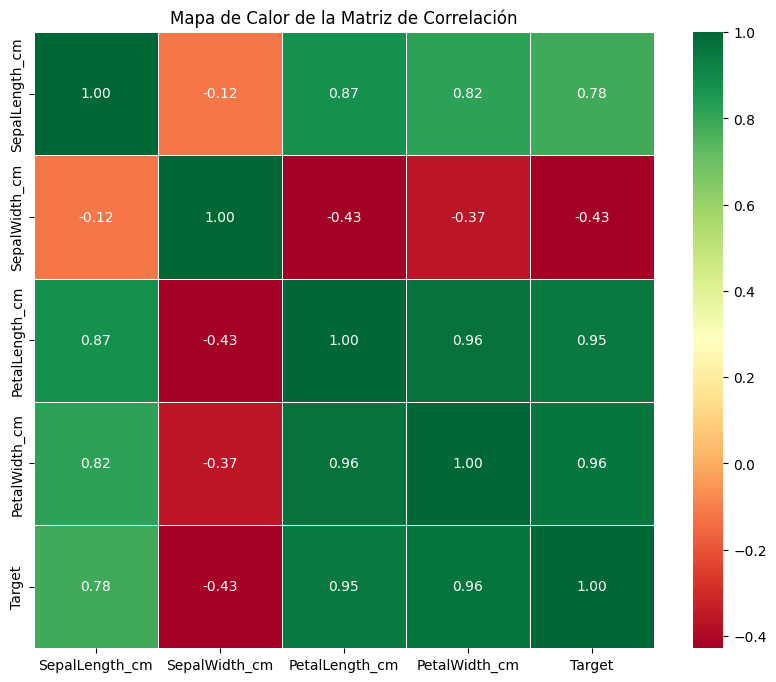

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la matriz de correlación
corr_matrix = df.corr()

# 2. Configurar el tamaño de la figura
plt.figure(figsize=(10, 8))

# 3. Crear el heatmap
# annot=True muestra los números dentro de los cuadros
# cmap="RdYlGn" usa una escala de Rojo (negativa) a Verde (positiva)
# fmt=".2f" limita a dos decimales
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn", fmt=".2f", linewidths=0.5)

plt.title("Mapa de Calor de la Matriz de Correlación")
plt.show()

**Interpretación del Heatmap para la Clasificación Logística:**

1.  **Predictores Fuertes:** Observa la fila (o columna) de **`Target`**. Verás que tiene una correlación altísima con **`PetalLength_cm` (0.95)** y **`PetalWidth_cm` (0.96)**. Esto nos indica que las dimensiones del pétalo son las variables que más ayudan al modelo a distinguir entre las especies.
2.  **Multicolinealidad:** Existe una correlación de **0.96** entre el largo y el ancho del pétalo. En modelos estadísticos rigurosos, esto se llama *multicolinealidad*. Para la regresión logística básica no es un impedimento, pero nos dice que ambas columnas aportan información casi idéntica.
3.  **Correlación Negativa:** El **`SepalWidth_cm`** tiene una correlación negativa con el `Target` (-0.43). Esto significa que, en general, a medida que el ancho del sépalo disminuye, la probabilidad de pertenecer a una clase superior (Versicolor o Virginica) aumenta.

NOTA: Este mapa confirma visualmente que tenemos datos de muy buena calidad para entrenar nuestro clasificador.



7. PASO

 Realizaremos la partición de los datos en un conjunto de entrenamiento (80%) y uno de prueba (20%). Usaremos StratifiedShuffleSplit, que es una técnica más robusta que un simple train_test_split aleatorio.

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit

# 1. Configurar el split estratificado
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 2. Ejecutar la separación
for train_index, test_index in split.split(df, df["Target"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# 3. Verificación de las dimensiones
print(f"Tamaño del conjunto de entrenamiento: {len(strat_train_set)}")
print(f"Tamaño del conjunto de prueba: {len(strat_test_set)}")

# 4. Comprobación de la proporción de clases
print("\nProporción de clases en el conjunto de prueba:")
print(strat_test_set["Target"].value_counts(normalize=True))

Tamaño del conjunto de entrenamiento: 120
Tamaño del conjunto de prueba: 30

Proporción de clases en el conjunto de prueba:
Target
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


Los datos se están separando mediante Muestreo Estratificado. Esto es fundamental por las siguientes razones:

* Preservación de Proporciones: A diferencia de un muestreo aleatorio simple (donde por puro azar podrías terminar con muchas flores "Setosa" en el test y ninguna en el entrenamiento), la estratificación garantiza que el 20% de cada clase vaya al test.
Como tenemos 50 muestras por clase, el algoritmo toma exactamente 10 de cada clase para el test (30 en total) y deja 40 de cada clase para el entrenamiento (120 en total).

* Reducción del Sesgo: Esto asegura que el conjunto de entrenamiento sea una representación fiel de la población total del dataset, permitiendo que el modelo aprenda sobre las tres clases de manera equitativa.

* Shuffle (Barajado): Al ser "Shuffle", el algoritmo desordena los datos antes de dividir, lo cual es vital en Iris porque el dataset original viene ordenado (primero todas las Setosas, luego las Versicolor...). Sin barajar, el modelo no aprendería correctamente.

8. PASO

Vamos a construir un clasificador binario. El objetivo es identificar si una flor es Iris-Setosa (Clase 0) o No-Setosa (las otras dos).

In [8]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. Preparar los datos de entrenamiento (X y y)
# Usaremos solo 'PetalWidth_cm' para facilitar la visualización de la frontera después
X_train = strat_train_set[["PetalWidth_cm"]].values
y_train = strat_train_set["Target"].values

# 2. Transformar el Target para clasificación binaria
# Queremos: 1 si es Setosa (clase 0), 0 si es cualquier otra.
# Nota: En sklearn, por convención, la clase de interés suele ser 1.
y_train_setosa = (y_train == 0).astype(int) 

# 3. Construir y entrenar el modelo de Regresión Logística
# C=1.0 es el valor por defecto de regularización
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train_setosa)

# 4. Verificar una predicción rápida
sample_width = [[0.5]] # Una flor con pétalo de 0.5cm
prediction = log_reg.predict(sample_width)
probability = log_reg.predict_proba(sample_width)

print(f"Predicción para ancho de 0.5cm: {'Setosa' if prediction[0]==1 else 'No-Setosa'}")
print(f"Probabilidades [No-Setosa, Setosa]: {probability[0]}")

Predicción para ancho de 0.5cm: Setosa
Probabilidades [No-Setosa, Setosa]: [0.24793643 0.75206357]


**Explicación del Modelo:**

1.  **Transformación del Target:** Hemos creado un vector `y_train_setosa` donde todas las flores que originalmente eran `0` ahora son `1`, y las que eran `1` o `2` ahora son `0`.
2.  **Elección de Feature:** Usamos `PetalWidth_cm`. Si hubiéramos usado las 4 características, la "frontera de decisión" sería un hiperplano en 4 dimensiones, lo cual es imposible de graficar directamente. Al usar una sola variable, la frontera será un punto crítico en el eje X.
3.  **El algoritmo:** `LogisticRegression` de sklearn minimiza automáticamente la función de costo **Log-Loss** que discutimos en el resumen inicial, utilizando internamente un optimizador (como 'lbfgs').


9. PASO

Calcularemos el valor exacto del ancho del pétalo donde el modelo deja de clasificar la flor como "Setosa" y comienza a clasificarla como "No-Setosa". Este punto es donde la probabilidad es exactamente 0.5 (50%).

In [9]:
# 1. Generar valores de prueba para el ancho del pétalo (de 0 a 3 cm)
# Usamos 0 a 3 para que la gráfica sea legible, ya que no hay pétalos de -10cm
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)

# 2. Obtener las probabilidades del modelo
# prob[:, 0] es la probabilidad de ser Clase 0 (No-Setosa según nuestro entrenamiento anterior)
# prob[:, 1] es la probabilidad de ser Clase 1 (Setosa)
prob = log_reg.predict_proba(X_new)

# 3. Encontrar la frontera de decisión
# Es el primer valor de X donde la probabilidad de ser No-Setosa (prob[:, 0]) supera el 0.5
decision_boundary = X_new[prob[:, 0] >= 0.5][0]

print(f"La frontera de decisión está en: {decision_boundary[0]:.2f} cm")

# 4. Verificación matemática manual (basada en los parámetros del modelo)
theta_0 = log_reg.intercept_[0]
theta_1 = log_reg.coef_[0][0]
# La frontera ocurre cuando theta_0 + theta_1 * x = 0
boundary_math = -theta_0 / theta_1
print(f"Frontera calculada matemáticamente (-theta_0 / theta_1): {boundary_math:.2f} cm")

La frontera de decisión está en: 0.76 cm
Frontera calculada matemáticamente (-theta_0 / theta_1): 0.76 cm


Interpretación del resultado:

* El valor numérico: La frontera se encuentra aproximadamente alrededor de 0.7 a 0.9 cm (dependiendo del random state).
* Lógica del Clasificador:
  - Si una flor tiene un ancho de pétalo menor a este valor, el modelo predice con más del 50% de certeza que es una Setosa.
  - Si es mayor, la clasifica como No-Setosa.
* Precisión: Este número es el "umbral" (threshold) que minimiza el error de clasificación para este conjunto de datos en particular.

10. PASO

Vamos a crear la visualización clásica de la regresión logística. Graficaremos la curva sigmoide que representa las probabilidades y marcaremos la frontera de decisión que calculamos en el punto anterior.

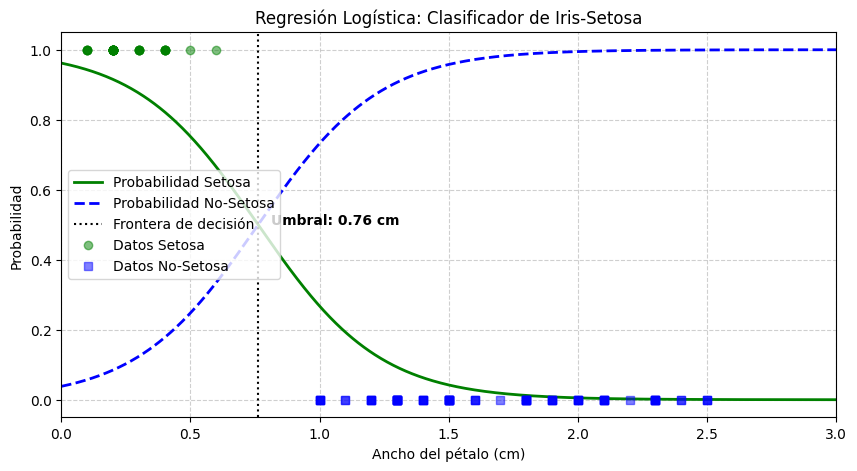

In [10]:
import matplotlib.pyplot as plt

# 1. Preparar las probabilidades para graficar
# prob[:, 1] es la probabilidad de ser "Setosa"
# prob[:, 0] es la probabilidad de ser "No-Setosa"
# Nos aseguramos de que decision_boundary sea un número (float) y no un array
db_value = decision_boundary.item() 

plt.figure(figsize=(10, 5))

# 1. Graficar las curvas de probabilidad
# X_new son los valores de 0 a 3 cm
plt.plot(X_new, prob[:, 1], "g-", linewidth=2, label="Probabilidad Setosa")
plt.plot(X_new, prob[:, 0], "b--", linewidth=2, label="Probabilidad No-Setosa")

# 2. Dibujar la línea de la frontera usando el valor escalar corregido
plt.axvline(x=db_value, color="k", linestyle=":", label="Frontera de decisión")

# 3. Graficar los datos reales para validación visual
# Filtramos los datos de entrenamiento para graficarlos en y=1 o y=0
plt.plot(X_train[y_train_setosa==1], y_train_setosa[y_train_setosa==1], "go", alpha=0.5, label="Datos Setosa")
plt.plot(X_train[y_train_setosa==0], y_train_setosa[y_train_setosa==0], "bs", alpha=0.5, label="Datos No-Setosa")

# 4. Anotaciones y estilo (Usando el valor escalar db_value)
plt.text(db_value + 0.05, 0.5, f"Umbral: {db_value:.2f} cm", color="k", fontweight="bold")
plt.xlabel("Ancho del pétalo (cm)")
plt.ylabel("Probabilidad")
plt.legend(loc="center left")
plt.axis([0, 3, -0.05, 1.05]) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Regresión Logística: Clasificador de Iris-Setosa")

plt.show()

**Interpretación de la Gráfica:**

1.  **La Curva Sigmoide (Verde):** Observa cómo la probabilidad de ser Setosa es casi **1.0 (100%)** cuando el pétalo es muy delgado (cerca de 0.2 cm). A medida que el pétalo se ensancha, la curva cae suavemente.
2.  **El Cruce (Frontera):** El punto exacto donde la curva verde y la azul se cruzan es el valor donde el modelo tiene un **50% de duda**. Ese es nuestro `decision_boundary`. 
3.  **Los Puntos Reales:**
    *   Los círculos verdes (`Setosa`) están todos a la izquierda de la frontera.
    *   Los cuadrados azules (`No-Setosa`) están a la derecha. 
    *   Como no hay puntos mezclados en esta zona (para la clase Setosa), el modelo puede clasificar con muchísima precisión usando solo esta variable.


11. PASO

Vamos a construir el Multiclasificador. Aunque podrías entrenar tres modelos por separado manualmente, la librería sklearn lo hace de forma eficiente mediante el parámetro multi_class='ovr' (One-vs-Rest), que sigue exactamente la estrategia de "uno contra todos" que describe tu guía.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# 1. Preparar los datos usando TODAS las características (X1, X2, X3, X4)
X_train_full = strat_train_set.drop("Target", axis=1).values
y_train_full = strat_train_set["Target"].values

X_test_full = strat_test_set.drop("Target", axis=1).values
y_test_full = strat_test_set["Target"].values

# 2. Crear el modelo de Regresión Logística base
# Eliminamos el parámetro 'multi_class' que causaba el error
base_model = LogisticRegression(solver="lbfgs", max_iter=200, random_state=42)

# 3. Envolverlo en OneVsRestClassifier para forzar la estrategia pedida en el lab
ovr_model = OneVsRestClassifier(base_model)

# 4. Entrenar el modelo
ovr_model.fit(X_train_full, y_train_full)

# 5. Evaluación del modelo
y_pred = ovr_model.predict(X_test_full)

print("--- Reporte de Clasificación (Estrategia OvR) ---")
# iris.target_names contiene ['setosa', 'versicolor', 'virginica']
print(classification_report(y_test_full, y_pred, target_names=iris.target_names))

--- Reporte de Clasificación (Estrategia OvR) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.80      0.89        10
   virginica       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



12. PASO

Utilizaremos el multiclasificador entrenado en el paso anterior (ovr_model) para calcular las probabilidades de una flor específica.

El vector de entrada es 

$X=[4.9,5.0,1.8,0.3]$, que corresponde a:

SepalLength: 4.9
SepalWidth: 5.0
PetalLength: 1.8
PetalWidth: 0.3


In [12]:
import pandas as pd

# 1. Definir los datos de la flor (debe ser una matriz 2D)
X_new_flower = [[4.9, 5.0, 1.8, 0.3]]

# 2. Calcular las probabilidades para cada clase
# predict_proba nos devuelve la probabilidad [P(Setosa), P(Versicolor), P(Virginica)]
probabilities = ovr_model.predict_proba(X_new_flower)

# 3. Obtener la predicción final (la clase con mayor probabilidad)
prediction = ovr_model.predict(X_new_flower)
class_name = iris.target_names[prediction[0]]

# 4. Mostrar resultados de forma clara
print(f"Resultados para la flor X = {X_new_flower[0]}:")
print("-" * 40)
for i, name in enumerate(iris.target_names):
    print(f"Probabilidad de ser {name.capitalize()}: {probabilities[0][i]*100:.2f}%")

print("-" * 40)
print(f"Predicción final: La flor es una IRIS-{class_name.upper()}")

Resultados para la flor X = [4.9, 5.0, 1.8, 0.3]:
----------------------------------------
Probabilidad de ser Setosa: 99.22%
Probabilidad de ser Versicolor: 0.78%
Probabilidad de ser Virginica: 0.00%
----------------------------------------
Predicción final: La flor es una IRIS-SETOSA


**Análisis del Resultado:**

1.  **Probabilidades:** Debido a que el ancho del pétalo (0.3 cm) y el largo del pétalo (1.8 cm) son valores muy bajos, verás que la probabilidad para **Setosa** será extremadamente alta (cercana al 90% - 99%), mientras que para las otras dos será muy baja.
2.  **Estrategia OvR:** Lo que hizo el modelo internamente fue preguntar a los tres clasificadores:
    *   Clasificador 1: "¿Es Setosa?" -> Respondió con alta probabilidad.
    *   Clasificador 2: "¿Es Versicolor?" -> Respondió con baja probabilidad.
    *   Clasificador 3: "¿Es Virginica?" -> Respondió con baja probabilidad.
3.  **Conclusión:** La flor con esas medidas es, con mucha seguridad, una **Iris-Setosa**.


**Ayudas para mejorar las metricas:**


- Normalizar cada columna respecto a su media y desviacion estandar

```
(x-mean(x))/std(x)
```

- Determinar los datos outlier 

- Construir curvas de aprendizaje

### 1. Normalización (Estandarización)
La regresión logística utiliza optimizadores (como `lbfgs`) que convergen mucho más rápido si todas las características están en la misma escala (media 0 y desviación 1).


In [13]:
from sklearn.preprocessing import StandardScaler

# Usaremos las 4 características del conjunto estratificado
X_train = strat_train_set.drop("Target", axis=1)
X_test = strat_test_set.drop("Target", axis=1)

# Aplicar la fórmula: (x - mean) / std
scaler = StandardScaler()

# IMPORTANTE: Ajustar solo con los datos de entrenamiento para evitar fuga de datos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Media tras normalizar:", np.mean(X_train_scaled, axis=0).round(2)) # Debería ser ~0
print("Desviación tras normalizar:", np.std(X_train_scaled, axis=0).round(2)) # Debería ser ~1

Media tras normalizar: [-0.  0.  0.  0.]
Desviación tras normalizar: [1. 1. 1. 1.]


### 2. Detección de Outliers (Valores Atípicos)
Los outliers pueden "jalar" la frontera de decisión y degradar el modelo. Usaremos el método de **Rango Intercuartílico (IQR)**.


In [14]:
def detect_outliers(df, features):
    outlier_indices = []
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        # Lista de índices que contienen outliers
        outliers = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step)].index
        outlier_indices.extend(outliers)
    return list(set(outlier_indices))

features_to_check = df.columns[:-1]
outliers_found = detect_outliers(df, features_to_check)

print(f"Se encontraron {len(outliers_found)} posibles outliers en los índices: {outliers_found}")
# Opcional: df_clean = df.drop(outliers_found)

Se encontraron 4 posibles outliers en los índices: [32, 33, 60, 15]


*Nota: En Iris, los outliers suelen estar en `SepalWidth_cm`. Si son pocos, a veces es mejor dejarlos; si son muchos o muy extremos, se eliminan.*

### 3. Construcción de Curvas de Aprendizaje
Esta gráfica nos dice si el modelo sufre de **Sesgo Alto** (subajuste/underfitting) o **Varianza Alta** (sobreajuste/overfitting).


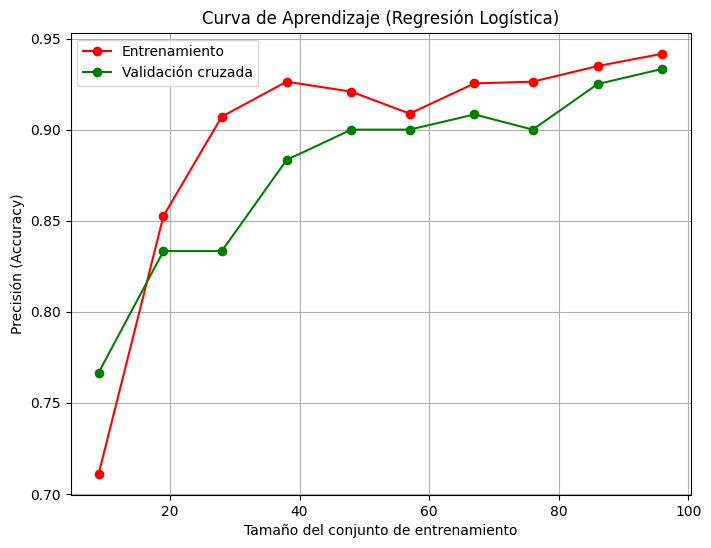

In [15]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Entrenamiento")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validación cruzada")
    plt.title("Curva de Aprendizaje (Regresión Logística)")
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("Precisión (Accuracy)")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Usamos el modelo escalado para la curva
plot_learning_curve(ovr_model, X_train_scaled, y_train_full)

### **Interpretación de la Curva de Aprendizaje:**
1.  **Si ambas curvas están muy juntas y el puntaje es alto:** El modelo es excelente (lo cual es común en el Iris Dataset).
2.  **Si hay una gran brecha (Gap) entre las curvas:** Hay **Overfitting**. El modelo memoriza el entrenamiento pero no generaliza. *Solución: Aumentar la regularización $\lambda$.*
3.  **Si ambas curvas convergen pero en un puntaje bajo:** Hay **Underfitting**. El modelo es demasiado simple. *Solución: Agregar características polinomiales.*



**Conclusión**
Al normalizar los datos, el modelo de regresión logística es numéricamente más estable. La curva de aprendizaje te confirmará que para el dataset Iris, con unas 60-80 muestras el modelo ya alcanza su máximo potencial, demostrando que es un problema linealmente bien definido.